# Short Course SC1: From Best-Guess to Better Decisions: Modern Optimisation for Water Distribution Systems
**WDSA/CCWI 2026** - Paphos, Cyprus, 18 May 2026

## Part 3: Optimal Water Network Design and Operation

Hands-on tutorial notebook — Part 3 of 3

Authors

* Christos Michalopoulos (christos.michalopoulos@kwrwater.nl) - Part 1
* Lydia Tsiami (lydia.tsiami@kwrwater.nl) - Part 2
* Dennis Zanutto (dennis.zanutto@kwrwater.nl) - Part 3

---

### Overview

This tutorial explores the modelling of **active element operations** within a water distribution system (WDS) design optimisation problem.

Introducing operational decisions into the optimisation problem raises several new modelling choices:

- Each network design likely has a preferred mode of operation — and conversely, the same control strategy cannot be applied uniformly across different system configurations.
- Operational control inherently implies **dynamic, time-dependent behaviour**, requiring a shift from single-period to extended-period simulation.

In this session, we will demonstrate:

1. **The Additional Challenges** — How the problem formulation evolves from a design-only, single-period simulation to an integrated extended-period simulation (EPS) problem.
2. **Optimisation Results Comparison** — Fixed operations vs. integrated design-and-operation optimisation.


### Notebook setup

Run the first two cells once to set up all the tools and libraries necessary to run this notebook.

In [ ]:
# Install conda on Colab (workaround to have its specific build tools on Colab)
!python --version
!pip install condacolab
import condacolab
condacolab.install()

Python 3.11.13
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:10
🔁 Restarting kernel...


: 

In [1]:
# Install PyGMO using conda (workaround to have PyGMO on Colab)
!python --version
!conda install pygmo
!pip install epyt

Python 3.11.11
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - pygmo


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _python_abi3_support-1.0   |       hd8ed1ab_2           8 KB  conda-forge
    ampl-asl-1.0.0             |       h5888daf_2         504 KB  conda-forge
    annotated-types-0.7.0      |     pyhd8ed1ab_1          18 KB  conda-forge
    anyio-4.13.0               |     pyhcf101f3_0         143 KB  conda-forge
    asttokens-3.0.1            |     pyhd8ed1ab_0          28 KB  conda-forge
    blis-2.0                   |pthreads_h64f13e8_3         3.9 MB  conda-forge
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates-2026.4.22  |       hbd8a1cb_0         128 KB  conda-forge
    cached-property-1.5.2      |       hd8ed1ab_1

In [2]:
# Import modules
from epyt import epanet
import pygmo
import numpy as np
from typing import Tuple
import matplotlib.pyplot as plt
import itertools
from tqdm import tqdm

### The Anytown Problem

The **Anytown** network is one of the most well-known benchmark problems in water distribution system optimisation, originally introduced in the context of the *Battle of the Network Models* (Walski et al., 1987). It has since become a standard testbed for combined design-and-operation optimisation.

> For full details, see the [Anytown entry on WaterBenchmarkHub](https://waterfutures.github.io/WaterBenchmarkHub/benchmarks/network-Anytown.html) and the [Centre for Water Systems benchmark page](https://www.exeter.ac.uk/research/centres/cws/resources/benchmarks/#a5).

The network consists of **19 junctions, 42 pipes, 1 pump station (3 parallel pumps), and 2 existing tanks**, supplied from a water treatment works maintained at a fixed head of 10 ft.

---

#### What Makes This Problem Hard?

**1. Three types of pipe decisions — simultaneously**

For each of the 35 existing pipes, the optimiser must choose between:
- **Cleaning and lining** — restoring the pipe's hydraulic capacity (Hazen-Williams C = 125)
- **Duplicating** — laying a parallel pipe in a new diameter
- **Do nothing** — leave the pipe as-is

In addition, **6 entirely new pipe links** must be added to the network.

**2. A location-dependent cost function**

Installation costs depend on *where* each pipe is located. The town has an **old city centre** (south-east of pipe 34) where excavations are significantly more expensive, and a surrounding **residential area**. The same 12-inch pipe costs $41.4/ft in the city but only $32.4/ft in a residential zone — a difference that must be accounted for across all pipe decisions.

**3. New tank siting and sizing**

Any node (except those already directly connected to a tank) is a candidate location for a **new storage tank**. Both the location and the volume must be optimised — with tank costs ranging from $115,000 (50,000 gal) to $600,000 (1,000,000 gal).

**4. Pump scheduling over 24 hours**

The pump station operations needs to be defined. Historically, this has been defined as the pumping station schedule over a **24-hour horizon with a 1-hour time step**. At each hour, the number of pumps running (0, 1, 2, or 3) must be decided. This adds **24 scheduling variables** to the problem and requires an Extended Period Simulation (EPS) to evaluate properly.

Energy costs are based on $0.12/kWh, with present-worth costs calculated over a 20-year amortisation period at 12% interest — so pump scheduling decisions directly affect the total cost objective.

**5. Multiple loading conditions to satisfy**

The design must be feasible under **5 different loading conditions**:
| Condition | Description | Min. pressure |
|---|---|---|
| Average day | Baseline daily demand | 40 psi |
| Instantaneous peak | 1.8× average day | 40 psi |
| Fire flow 1, 2, 3 | 1.3× peak day + fire demand | 20 psi |

Fire flow conditions assume tanks start at their *low* operating level and one pump is out of service — the worst-case stress test for the system.

---

#### Why Does This Require Extended Period Simulation?

Unlike a single-period design problem, the pump scheduling decisions mean the system state — particularly **tank water levels** — evolves over time. A valid solution must ensure that:
- Tank levels stay within operational bounds (225–250 ft) throughout the 24-hour cycle
- All tanks empty and refill over their operational range within each day
- Emergency storage (below 225 ft, down to 215 ft) is never drawn on during normal operations

This time-dependency is what forces us from a simple steady-state hydraulic solve into a full **extended period simulation**, and it is the central challenge of this part of the tutorial.


EPANET version 20305 loaded (EPyT version v2.3.5.0 - Last Update: 20/02/2026).
Publication DOI: https://zenodo.org/records/18484878
Input File anytown-exeter.inp loaded successfully.



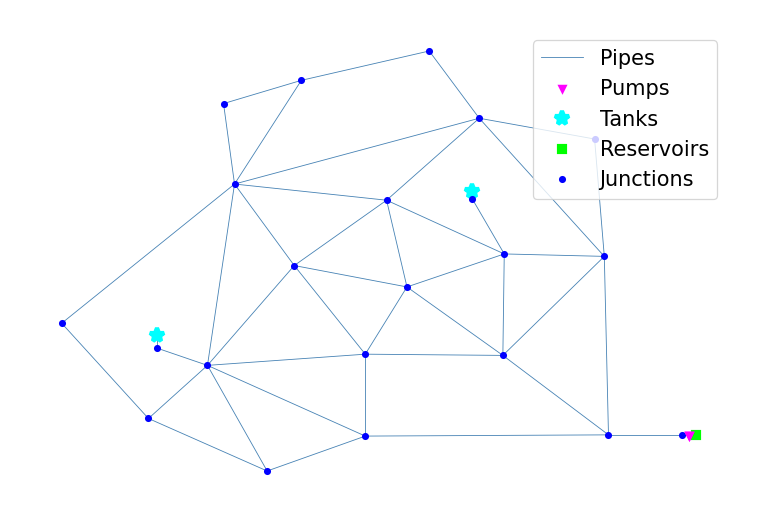

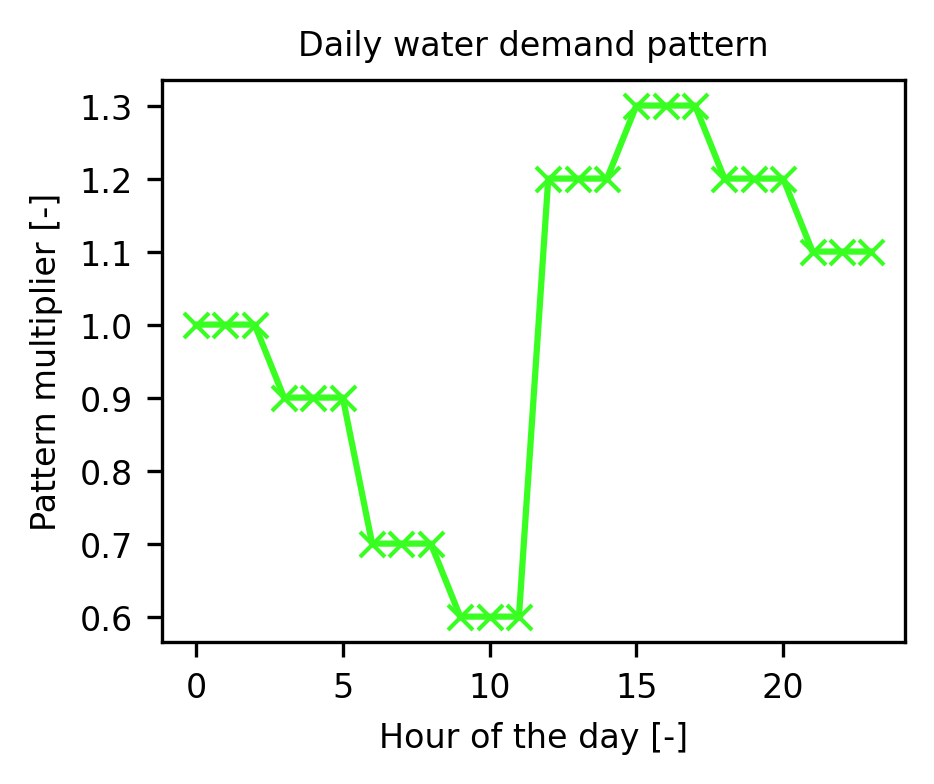

In [8]:
# View network and water demand pattern
anytown_network = epanet('anytown-exeter.inp')
anytown_network.plot();

DEMAND_PATTERN = anytown_network.getPattern()[0]
anytown_network.plot_ts(
    X=range(24),
    Y=DEMAND_PATTERN,
    title="Daily water demand pattern",
    xlabel="Hour of the day [-]",
    ylabel="Pattern multiplier [-]"
  )
# PS: run twice to remove notebook warnings

#### Challenges of Extended Period Simulation and Dynamic Control Elements

##### How EPANET Advances Through Time: Forward Euler

EPANET solves the full hydraulic state of the network at each time step (pressures, flows, tank levels) using an iterative steady-state solver. To advance through time, it uses a **forward (explicit) Euler** scheme: the hydraulic state at time $t$ is used to compute flows into/out of tanks, and those flows are assumed **constant** for the entire interval $\Delta t$ to project the system state at $t + \Delta t$.

$$V_{\text{tank}}(t + \Delta t) = V_{\text{tank}}(t) + Q_{\text{tank}}(t) \cdot \Delta t$$

This is simple and cheap, but the approximation error grows with $\Delta t$ — the coarser the time step, the less faithfully tank dynamics are captured.

---

##### Time Step Resolution and the Cost-Accuracy Trade-off

EPANET exposes two distinct time parameters, which are **not the same thing**:

| Parameter | Role |
|---|---|
| **Hydraulic time step** | How often the network state is recomputed and advanced |
| **Reporting time step** | How often results are written to the output |

The hydraulic time step directly controls how many hydraulic solves are performed per simulation:

| Hydraulic time step | Solves per 24-hour day |
|---|---|
| 1 second | 86,400 |
| 5 minutes | 288 |
| 1 hour | 24 |

In an optimisation context, every candidate solution requires at least one full EPS. **A finer time step multiplies the computational cost of every function evaluation.** The common engineering practice is therefore:

> Run the optimisation at a **coarser resolution** (e.g., 1-hour steps), then re-evaluate promising solutions at **higher fidelity** (e.g., 5-minute steps) as a post-processing check.

Resolution also changes results numerically — a solution that appears feasible at 1-hour resolution may violate pressure or tank-level constraints when re-evaluated at finer resolution. This is a known source of optimistic bias in the optimisation results.

---

##### The Hidden Timestep Problem: Event-Triggered Intermediate Steps

This is where things get subtle. EPANET does **not** advance through time in uniform steps only. Whenever one of the following events occurs, EPANET automatically inserts an **extra intermediate time step**:

- A tank reaches its upper or lower operating level (fills or empties)
- A rule-based control or time-based control fires (e.g., a pump switches on or off)
- A pattern interval boundary is crossed

This has two important consequences for optimisation:

**1. Variable-length output.** Because the number of intermediate steps depends on system behaviour, two different candidate solutions will produce result arrays of **different lengths**. You cannot simply index `results[i]` and expect to compare the same physical time across candidates — the timestamps must always be carried alongside the values.

**2. Invisible dynamics between reporting steps.** Results are only written at *reporting* time steps — the intermediate steps are used internally but never appear in the output. This means:
```
Reporting step:   tR1 ──────────────────────────────────── tR2
Actual dynamics:  tR1 ── [tank fills] ── [tank empties] ── tR2
What you see:      level at tR1                             level at tR2
```

If the reporting interval is too coarse, a tank could **fill completely and then drain** between two consecutive output rows and your objective function would never see it. Energy consumption is computed correctly by EPANET internally, but any other metric relying on node or link observations (e.g. reliability index) computed from reporting-step values alone will produce inaccurate estimates.

> **Key takeaway:** Always use the `runH` / `nextH` loop to step through the simulation and capture results at **every hydraulic time step**, not only at reporting time steps or multiples of the hydraulic time step. This is the only way to observe the full system dynamics, including event-triggered intermediate steps.

### Code of a Simplified, Design-only Anytown Problem

We define a **simplified version** of the design-only Anytown Problem that preserves the core modelling challenges while keeping the implementation tractable within a Python Jupyter notebook.

---

#### Load Scenarios

The full Anytown problem requires feasibility under many loading conditions: average day, instantaneous peak, and fire flow scenarios.

> **Simplification:** Only the **24-hour EPS average day cycle** is evaluated. The rationale is that pump scheduling decisions (the control variables) only affect the system's dynamic behaviour under the daily demand pattern — fire flow and peak conditions are static snapshots that do not interact with the pump schedule. This keeps every function evaluation to a single EPS run.

---

#### Decision Variables

The optimiser controls two groups of variables:

**Design variables** (modify the network elements):

| Variable group | Type | Description |
|---|---|---|
| New pipes | Integer ∈ {0, ..., $n^{PIPE\ OPTIONS}$-1} | Index of the list of available diameter options | 
| Rehabilitation pipes | Integer ∈ {-1, 0, ..., $n^{PIPE\ OPTIONS}$-1} | Like new pipes plus a do-nothing option represented by '-1' |


> **Simplification:** Tank siting and sizing are excluded. Cleaning and lineing of existing pipes is excluded.

**Operational variables** (time-dependent, one per hour):

| Variable group | Type | Description |
|---|---|---|
| Pump schedule | Integer ∈ {2, 3} | Number of pumps running during each of the 24 hourly time steps |

> **Simplification:** We restrict pump operation to either 2 or 3 pumps at all times (no zero-pump or single-pump hours).

---

#### Constraints

The simulation is run in **Pressure-Driven Analysis (PDA)** mode rather than the classic demand-driven mode. In PDA, nodes receive less than their requested demand when pressure is insufficient, rather than the solver failing to converge.

This means hydraulic feasibility is *always* guaranteed, and infeasibility is instead expressed as a **continuous quantity** — the total undelivered demand across all nodes and all time steps:

$$U = \sum_{t} \sum_{i} \left( d_i^{\text{requested}}(t) - d_i^{\text{delivered}}(t) \right)\cdot \Delta_t$$

> **Simplification:** Tank operational constraints (the requirement that tanks complete a full fill-empty cycle within 24 hours) are not enforced. In the full problem this prevents solutions that exploit tank storage without replenishing it, but we start from empty tanks.

---

#### Objectives

The problem is formulated as a **bi-objective** optimisation. The two objectives and how they interact depend on whether the current solution is hydraulically feasible.

**Objective 1 — Design cost proxy:**

$$f_1 = \text{Total volume of new \& rehabilitated pipe}$$

> **Simplification:** Rather than computing the full cost function (which depends on pipe location, diameter, and rehabilitation type), we use the **total replaced pipe volume** as a lightweight proxy for capital cost. This preserves the trade-off structure without requiring the full cost table lookup at every evaluation.

**Objective 2 — Pressure satisfaction or energy cost:**

This is where the formulation makes a deliberate modelling choice. A solution that does not fully satisfy demand is *not comparable* to one that does — they represent different levels of service. We therefore use a **conditional objective**:

$$
f_2(\mathbf{x}) =
\begin{cases}
U_{\text{norm}} & \text{if } U > 0 \quad \text{(infeasible: minimise undelivered demand)} \\[6pt]
-\dfrac{1}{E_{\text{total}}} & \text{if } U = 0 \quad \text{(feasible: minimise energy cost)}
\end{cases}
$$

where $U$ is the total undelivered demand across all nodes and time steps, $U_{\text{norm}}$ is its normalised value, and $E_{\text{total}}$ is the total pumping energy consumed over the 24-hour horizon.

The logic works in two stages:

1. **Infeasible solutions** (`total_undelivered_demand > 0`): $f_2$ is the normalised undelivered demand — a positive value that the optimiser tries to minimise toward zero. This acts as a **soft constraint**, steering the search toward the feasible region without hard rejection.

2. **Feasible solutions** (`total_undelivered_demand = 0`): $f_2$ switches to $-1/E_{\text{total}}$, where $E_{\text{total}}$ is the total pumping energy consumed over the 24-hour horizon. Minimising $-1/E$ is equivalent to minimising $E$. The reciprocal formulation ensures that feasible solutions are **always preferred over infeasible ones** in the objective space — no infeasible solution can accidentally dominate a feasible one.

> This conditional structure is a common pragmatic trick in engineering optimisation: rather than using a penalty term with an arbitrary weight, the objective *changes meaning* once feasibility is achieved, creating a natural separation between the two regions of the search space.

In [17]:
class AnytownDesignProblem:
  """
  Simplified version of the Anytown problem with only pipe interventions as decision variables (design-only).
  """

  AVAILABLE_DIAMETERS = np.array([6, 8, 10, 12, 14, 16, 18, 20, 24, 30]) # inches

  # Index helpers for pipes' decision variables
  SMALLEST_DIAM_OPTION = 0
  BIGGEST_DIAM_OPTION = len(AVAILABLE_DIAMETERS)-1
  DO_NOTHING_OPTION = -1

  NEW_PIPES_ID = ["110", "113", "114", "115", "116", "125"]

  # We exclude these two short pipes (1 ft) that are in the model mainly
  # for visualization purposes
  EXC_PIPES_ID = ["142", "143"]

  # REH_PIPES_ID: existing pipes for rehabilitation are all other pipes that are not NEW PIPES or EXC PIPES

  # Problem parameters:
  # Roughness of a new pipe. Rgh. needs to be updated when replacing an existing pipe.
  NEW_PIPE_RGH_C = 130

  PUMPS_ID = ["78", "79", "80"]
  PUMPS_PATTERNS_ID = ["2", "3", "4"] # Each pump has an associated pattern representing its schedule

  # Instead of minimum pressure formulation we use PDA so use the more stringent pressure requirement as target pressure and the less stringent one as minimum pressure.
  TARGET_PRESSURE = 40 # psi
  MIN_PRESSURE = 20 # psi

  # Nodes on which to check minimum pressure and undelivered demand
  DEMAND_NODES_ID = [
    "1", "2", "3", "4", "5" , "6", "7", "8", "9", "10",
    "11", "12", "13", "14", "15", "16", "17", "18", "19",
  ]

  # Problem characteristics
  N_OBJECTIVES = 2
  N_INEQUALITY_CONSTRAINTS = 0
  N_EQUALITY_CONSTRAINTS = 0

  def __init__(self, pumping_station_pattern: list[int]) -> None:
    """
    Initialise the problem using the network loaded at module level.
    Since it is a design-only problem, the pumping station's schedule
    is a problem parameter. Thus, we set it according to the input
    at init time, as all pumps are always off in the inp file.
    """
    # We simply offload the init to the following sub-functions
    self._init_network()
    self._init_EN_helpers()
    self._init_bounds()
    self._apply_pstat_pattern(
        pattern=np.array(pumping_station_pattern)
    )
    self._init_fitness_bounds()

  #--------------------------------------------------------------#
  #                MANDATORY PYGMO METHODS                       #
  #--------------------------------------------------------------#

  def get_bounds(self) -> Tuple[np.ndarray, np.ndarray]:
    return self.lb, self.ub

  def get_nix(self) -> int:
    return len(self.lb) # All decision variables are integers

  def get_nobj(self) -> int:
    return self.N_OBJECTIVES

  def get_nic(self) -> int:
    return self.N_INEQUALITY_CONSTRAINTS

  def get_nec(self) -> int:
    return self.N_EQUALITY_CONSTRAINTS

  def fitness(self, x: np.ndarray) -> np.ndarray:
    self._apply_dvs(x)
    fv = self._compute_fitness(x)
    self._reset_dvs(x)
    return fv
  
  #--------------------------------------------------------------#
  #                END OF MANDATORY PYGMO METHODS                #
  #--------------------------------------------------------------#

  def _init_network(self) -> None:
    """
    Override the default configurations of the EPANET Anytown network.
    
    The network is not stored on the instance as EPyT objects are not
    serialisable (picklable), making them incompatible with parallel
    optimisation frameworks that copy or distribute the problem object.
    Instead, the fitness function accesses the network directly from
    the global (module-level) scope.
    """
    anytown_network.setTimeHydraulicStep(60*15) # 15 minute hydraulic time step
    anytown_network.setDemandModel('PDA', self.MIN_PRESSURE, self.TARGET_PRESSURE, 0.5)

  def _init_EN_helpers(self) -> None:
    """
    Cache static network properties that remain constant across all evaluations.
    Since the network topology never changes, these values are computed once
    at initialisation rather than re-queried from EPANET on every fitness call.
    """

    # Let's get which pipes can be rehabilitated: all those that are not new or excluded on purpose
    self.REH_PIPES_ID = [
        link_id
        for link_id, link_type in zip(
            anytown_network.getLinkNameID(),
            anytown_network.getLinkType()
        )
        if (
            link_type == 'PIPE' and
            link_id not in self.NEW_PIPES_ID and
            link_id not in self.EXC_PIPES_ID
        )
    ]

    # Let's cache the EPANET indexes of the pipe on which we will work on
    self.NEW_PIPES_ENIDX = [
        anytown_network.getLinkIndex(p)
        for p in self.NEW_PIPES_ID
    ]
    self.REH_PIPES_ENIDX = [
        anytown_network.getLinkIndex(p)
        for p in self.REH_PIPES_ID
    ]

    # Let's cache the original pipes' diameter and roughness for pipes that we
    # will rehabilitate. When we install a new pipe on an existing one (rehab.)
    # we will change its diameter and roughness in place to avoid network modifications.
    self.REH_PIPES_ORIG_DIAM = anytown_network.getLinkDiameter(self.REH_PIPES_ENIDX)
    self.REH_PIPES_ORIG_RGH_C = anytown_network.getLinkRoughnessCoeff(self.REH_PIPES_ENIDX)

    # As we did for the pipes, we store the EPANET index of the pump patterns
    # so that we can change their controls if necessary
    self.PUMPS_PATTERNS_ENIDX = anytown_network.getPatternIndex(self.PUMPS_PATTERNS_ID)

    # Once again, we extract the pumps index (index in the list of links) to extract
    # the results. However, we are going to extract them from a 2d np.array so we need
    # the Python indexes (starts from 0) alongside the EPANET index (starts from 1)
    self.PUMPS_ENIDX = [
        anytown_network.getLinkIndex(p)
        for p in self.PUMPS_ID
    ]
    self.PUMPS_IDX = [i-1 for i in self.PUMPS_ENIDX]

    # Same thing for the demand nodes, let's cache the EPANET and Python index
    # of the demand nodes on which we need to check the minimum pressure/undeliv. demand
    self.DEMAND_NODES_ENIDX = [
        anytown_network.getNodeIndex(n)
        for n in self.DEMAND_NODES_ID
    ]
    self.DEMAND_NODES_IDX = [i-1 for i in self.DEMAND_NODES_ENIDX]

  def _init_bounds(self) -> None:
    """
    Pre-compute and store the decision variable bounds.
    Called once at initialisation so that get_bounds() can return the
    stored values directly, without recomputing them at every call.
    """
    # New pipes must be installed. Thus, each pipe decision variable is an integer
    # representing the index in the list of available diameters.
    lb_new_pipe = self.SMALLEST_DIAM_OPTION
    ub_new_pipe = self.BIGGEST_DIAM_OPTION
    n_new_pipes = len(self.NEW_PIPES_ID)

    # Existing pipes (rehabilitate) can be ignored (do-nothing option) or replaced 
    # by a new pipe with any diameter. Same approach as the new pipes (index of the list)
    # but with the do-nothing option as lower bound.
    lb_reh_pipe = self.DO_NOTHING_OPTION
    ub_reh_pipe = self.BIGGEST_DIAM_OPTION
    n_reh_pipes = len(self.REH_PIPES_ID)

    # Finally let's compose the decision variable bounds. We place new pipes first.
    self.lb = np.array(
      [lb_new_pipe]*n_new_pipes + [lb_reh_pipe]*n_reh_pipes
    )
    self.ub = np.array(
      [ub_new_pipe]*n_new_pipes + [ub_reh_pipe]*n_reh_pipes
    )

  def _init_fitness_bounds(self) -> None:
    """
    Pre-compute normalisation bounds for each metric where possible.

    1. Design cost proxy (total pipe volume): exact bounds are computable.
       The minimum is achieved by selecting the smallest available option
       for every pipe decision variable (new pipes + rehabilitation pipes).
       The maximum is achieved by selecting the largest option for all of them.

    2. Energy cost: no analytical bounds are available. The energy consumed
       depends on the full hydraulic simulation, which cannot be short-circuited.

    3. Undelivered demand: the minimum is zero (all demand met); the maximum
       is the total system demand (nothing delivered anywhere).
    """
    total_net_vol = 0.0
    # Compute the new pipes' subnetwork volume (must be installed, hence smallest diam option)
    total_net_vol += self._compute_subnetwork_volume(
        np.full(shape=(len(self.NEW_PIPES_ID),), fill_value=self.SMALLEST_DIAM_OPTION),
        self.NEW_PIPES_ENIDX
    )
    # Compute the rehabilitation pipes' subnetwork volume (can avoid install, hence do noting option)
    total_net_vol += self._compute_subnetwork_volume(
        np.full(shape=(len(self.REH_PIPES_ID),), fill_value=self.DO_NOTHING_OPTION),
        self.REH_PIPES_ENIDX
    )
    self.TOTAL_NETWORK_VOLUME__MIN = total_net_vol

    # Same calculation but for the biggest possible pipe option
    total_net_vol = 0.0
    total_net_vol += self._compute_subnetwork_volume(
        np.full(shape=(len(self.NEW_PIPES_ID),), fill_value=self.BIGGEST_DIAM_OPTION),
        self.NEW_PIPES_ENIDX
    )
    total_net_vol += self._compute_subnetwork_volume(
        np.full(shape=(len(self.REH_PIPES_ID),), fill_value=self.BIGGEST_DIAM_OPTION),
        self.REH_PIPES_ENIDX
    )
    self.TOTAL_NETWORK_VOLUME__MAX = total_net_vol

    self.UNDELIVERED_DEMAND__MIN = 0.0
    self.UNDELIVERED_DEMAND__MAX = sum(anytown_network.getNodeBaseDemands()[1])*60*24 # Gallons per day

  def _apply_dvs(self, x: np.ndarray) -> None:
    """
    Apply the decision variables vector x to the problem and the anytown_network object
    """
    # As set up in the init bounds function, first we put the decision variables
    # of the n new pipes, then we leave the decision variables of the rehab pipes.
    n_new_pipes_dvs = len(self.NEW_PIPES_ID)
    n_reh_pipes_dvs = len(self.REH_PIPES_ID)
    n_all_pipes_dvs = n_new_pipes_dvs + n_reh_pipes_dvs
    new_pipes_dvs = x[0:n_new_pipes_dvs].astype(int)
    reh_pipes_dvs = x[n_new_pipes_dvs:n_all_pipes_dvs].astype(int)

    self._apply_pipe_dvs(new_pipes_dvs, self.NEW_PIPES_ENIDX)
    self._apply_pipe_dvs(reh_pipes_dvs, self.REH_PIPES_ENIDX)

  def _reset_dvs(self, x: np.ndarray) -> None:
    """
    Reset the problem and the anytown network object to thier original values
    before applying the x solution
    """
    # No need to reset the new pipes as we overwrite them at every evaluation of a solution
    # While we must do it for the rehabilitated pipes
    self._reset_pipe_dvs(
        self.REH_PIPES_ENIDX,
        self.REH_PIPES_ORIG_DIAM,
        self.REH_PIPES_ORIG_RGH_C
    )

    return

  def _apply_pipe_dvs(self, pipes_dvs: np.ndarray, pipes_ENidx: list[int]) -> None:
    """
    Apply the pipe diameter option for a list of pipes
    """
    for pipe_ENidx, pipe_dv in zip(pipes_ENidx, pipes_dvs):
      if pipe_dv == self.DO_NOTHING_OPTION:
        continue

      diameter_option = self.AVAILABLE_DIAMETERS[pipe_dv]

      anytown_network.setLinkDiameter(pipe_ENidx, diameter_option)
      anytown_network.setLinkRoughnessCoeff(pipe_ENidx, self.NEW_PIPE_RGH_C)

    return

  def _reset_pipe_dvs(
      self,
      pipes_ENidx: list[int],
      pipes_orig_diams: list[float],
      pipes_orig_rgh_c: list[float]
  ) -> None:
    """
    Reset the pipe diameter and roughness of a pipe to its original values
    """
    anytown_network.setLinkDiameter(pipes_ENidx, pipes_orig_diams)
    anytown_network.setLinkRoughnessCoeff(pipes_ENidx, pipes_orig_rgh_c)

    return

  def _apply_pstat_pattern(self, pattern: np.ndarray) -> None:
    """
    Apply a pumping station pattern to the problem and the anytown_network object
    Pattern must be 24 values long and representing the number of pumps of the 
    pumping station running.
    """
    assert len(pattern) == 24 and all(pattern >= 0 ) and all(pattern <= len(self.PUMPS_PATTERNS_ID)), \
      "We expect a pumping pattern with 24 values (one per hour of the day) and containing the number of pumps running at that hour"

    for i, pump_pattern_ENidx in enumerate(self.PUMPS_PATTERNS_ENIDX):
      pump_pattern = (pattern > i).astype(float)

      anytown_network.setPattern(pump_pattern_ENidx, pump_pattern)

    return

  def _compute_fitness(self, x: np.ndarray) -> np.ndarray:
    """
    Effectively compute the fitness of a decision vector after it has been applied
    to the problem.
    """

    # First objective: total network volume replaced
    total_net_vol = 0.0
    # As set up in the init bounds function, first we put the decision variables
    # of the n new pipes, then we leave the decision variables of the rehab pipes.
    n_new_pipes = len(self.NEW_PIPES_ID)
    new_pipes_dvs = x[0:n_new_pipes].astype(int)
    reh_pipes_dvs = x[n_new_pipes:].astype(int)

    total_net_vol += self._compute_subnetwork_volume(
        new_pipes_dvs,
        self.NEW_PIPES_ENIDX
    )
    total_net_vol += self._compute_subnetwork_volume(
        reh_pipes_dvs,
        self.REH_PIPES_ENIDX
    )

    # Second objective: total energy consumption (needs simulation)
    # getComputedHydraulicTimeSeries returns all values, including additional 
    # intermediate time steps that EPANET may introduce because of tanks.
    hyd_results = anytown_network.getComputedHydraulicTimeSeries([
      'DemandRequested',
      'DemandDelivered',
      'Energy',
    ])

    total_energy = np.sum(hyd_results.Energy[:, self.PUMPS_IDX])

    # Third objective: undelivered demand (we normalise it)
    udemands = (
        hyd_results.DemandRequested[:, self.DEMAND_NODES_IDX] -
        hyd_results.DemandDelivered[:, self.DEMAND_NODES_IDX]
    ) # gpm
    #--------------------------------------------------------
    #                    WRONG APPROACH
    #--------------------------------------------------------
    # Flows are in GPM so to get the total amount of flow you
    # need to integrate over time and know for how long each 
    # simulation is valid.
    total_udemands = np.sum(udemands)*60 # Gallons per day

    #--------------------------------------------------------
    #                    CORRECT APPROACH
    #--------------------------------------------------------
    # First you get the delta t (how long each snapshot is valid)
    # The integrate 
    delta_t = hyd_results.Time[1:] - hyd_results.Time[:-1]
    delta_t = np.append(delta_t, 0)
    udemands_gps = udemands/60
    total_udemands = np.sum(udemands_gps*delta_t[:, np.newaxis])*60*60 # Gallons per day

    normalised_demands = (total_udemands - self.UNDELIVERED_DEMAND__MIN)/(
        self.UNDELIVERED_DEMAND__MAX - self.UNDELIVERED_DEMAND__MIN
    )
    # let's round it so that we don't get too many points with similar undelivered
    # demands as we don't care about those solutions.
    normalised_demands = np.round(normalised_demands, 1)

    # Conditional second objective: first satisfy the constraint, once that
    # is done, focus on minimising the energy
    if total_udemands > 0:
      return np.array([
          total_net_vol,
          normalised_demands
      ])

    return np.array([
        total_net_vol,
        -1/total_energy # invert and change sign to mantain minimization direction of energy
      ])

  def _compute_subnetwork_volume(self, pipes_dvs: np.ndarray, pipes_ENidx: list[int]) -> float:
    """
    Return the total network volume replaced by the decision vector on the list of pipes
    """
    total_volume = 0.0
    for pipe_ENidx, pipe_dv in zip(pipes_ENidx, pipes_dvs):
      if pipe_dv == self.DO_NOTHING_OPTION:
        continue

      pipe_diam = self.AVAILABLE_DIAMETERS[pipe_dv] / 12 # feet
      pipe_length = anytown_network.getLinkDiameter(pipe_ENidx)

      total_volume += 3.14 * pipe_diam * pipe_diam /4 * pipe_length

    return total_volume

### Run the Optimisation (1)

We solve the simplified Anytown problem as a **multi-objective optimisation** using **NSGA-II** (Non-dominated Sorting Genetic Algorithm II), a well-established evolutionary algorithm in WDS optimisation.

> It is a **single execution** with a random seed for the initial population and another fort the stochastic operators of the algorithm. Every time you run this cell you will get different results.

In [18]:
# Define helper functions

# Ignore UserWarning from epyt about "may be hydraulically unstable" (It means it converged but it took more trials than allowed)
import warnings
warnings.filterwarnings("ignore", message="WARNING: System may be hydraulically unstable.", module="epyt.src.epanetapi")

def run_optimisation(
        prob,
        n_generations: int,
        pop_size: int
    ):
    """
    Run the optimisation of a given problem for a given number of generations and 
    population size using NSGA-II.
    """
    pg_prob = pygmo.problem(prob)
    pg_algo = pygmo.algorithm(pygmo.nsga2(gen=n_generations))
    pg_pop = pygmo.population(pg_prob, size=pop_size)

    pg_pop_final = pg_algo.evolve(pg_pop)
    
    return pg_pop_final

def view_valid_pareto(pop, color, label):
    """
    Creates a 2d plot with the valid portion of the Pareto front from a population.
    As we included the constraint on undelivered demand as part of the second objective,
    positive values of the second objective mean solutions with undelivered demand.
    We also re-convert the valid part of the front back to energy (-1/x)
    """

    fvs = pop.get_f()
    # Keep only the points satisfying the constraint
    fvs = fvs[fvs[:,1] < 0]

    # Revert back to energy
    fvs[:, 1] = -1/fvs[:, 1]
    
    # Basic matplotlib scatter plot
    plt.scatter(fvs[:,0], fvs[:,1], c=color, alpha=0.7, label=label)

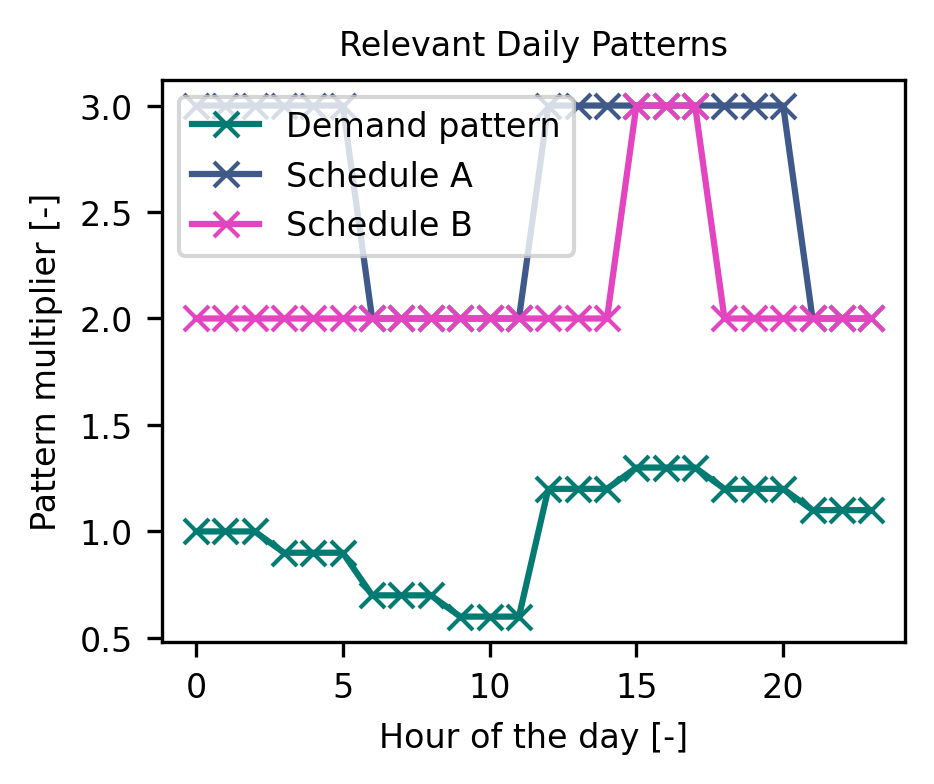

In [19]:
# Create two design problems with two different schedules and visualize them
PUMPING_STATION_SCHEDULE_A = [3]*6+[2]*6+[3]*9+[2]*3
PUMPING_STATION_SCHEDULE_B = [2]*15+[3]*3+[2]*6

anytown_network.plot_ts(
    X=range(24),
    Y=np.vstack([
        DEMAND_PATTERN,
        PUMPING_STATION_SCHEDULE_A,
        PUMPING_STATION_SCHEDULE_B
      ]).T,
    title="Relevant Daily Patterns",
    xlabel="Hour of the day [-]",
    ylabel="Pattern multiplier [-]",
    labels=[
        "Demand pattern",
        "Schedule A",
        "Schedule B",
    ]
  )
  
design_prob_a = AnytownDesignProblem(
    pumping_station_pattern=PUMPING_STATION_SCHEDULE_A
)
design_prob_b = AnytownDesignProblem(
    pumping_station_pattern=PUMPING_STATION_SCHEDULE_B
)

In [20]:
# Run the optimisation for problem A (every time slightly different results)
sol_design_prob_a = run_optimisation(design_prob_a, n_generations=100, pop_size=200)

In [21]:
# Run the optimisation for problem B (every time slightly different results)
sol_design_prob_b = run_optimisation(design_prob_b, n_generations=100, pop_size=200)

/usr/local/lib/python3.11/site-packages/epyt/src/epanetapi.py:1116: UserWarning: WARNING: System hydraulically unbalanced.
  warnings.warn(errmssg.value.decode())
/usr/local/lib/python3.11/site-packages/epyt/src/epanetapi.py:1116: UserWarning: WARNING: System hydraulically unbalanced.
  warnings.warn(errmssg.value.decode())
/usr/local/lib/python3.11/site-packages/epyt/src/epanetapi.py:1116: UserWarning: WARNING: System hydraulically unbalanced.
  warnings.warn(errmssg.value.decode())
/usr/local/lib/python3.11/site-packages/epyt/src/epanetapi.py:1116: UserWarning: WARNING: System hydraulically unbalanced.
  warnings.warn(errmssg.value.decode())
/usr/local/lib/python3.11/site-packages/epyt/src/epanetapi.py:1116: UserWarning: WARNING: System hydraulically unbalanced.
  warnings.warn(errmssg.value.decode())
/usr/local/lib/python3.11/site-packages/epyt/src/epanetapi.py:1116: UserWarning: WARNING: System hydraulically unbalanced.
  warnings.warn(errmssg.value.decode())
/usr/local/lib/python3

### Compare the Optimisation Results (1)

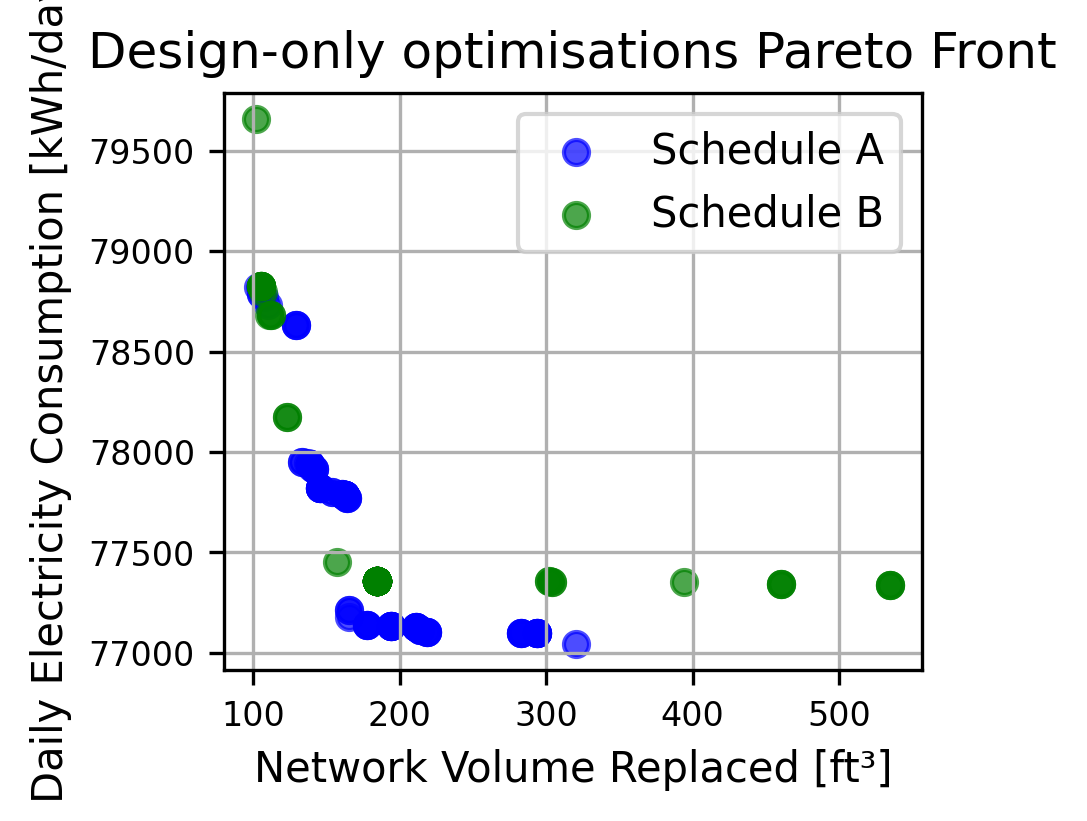

In [22]:
# Visualize the result of the optimisation for problems A and B
plt.figure(figsize=(3,2.5))
view_valid_pareto(sol_design_prob_a, color='b', label="Schedule A")
view_valid_pareto(sol_design_prob_b, color='g', label="Schedule B")
plt.xlabel("Network Volume Replaced [ft³]")
plt.ylabel("Daily Electricity Consumption [kWh/day]")
plt.title("Design-only optimisations Pareto Front")
plt.grid(True)
plt.legend()
plt.show()

**1. Silent hydraulic errors**

EPANET may encounter convergence issues during the EPS and report them as error or warning codes. In this implementation, `getComputedHydraulicTimeSeries` returns all simulated values — including any additional intermediate time steps introduced by tank events (as highlighted in one of the challenges earlier) — but does **not** expose the error codes themselves. We therefore have no way of knowing whether a given candidate solution produced a valid hydraulic simulation or a quietly degraded one.

The correct approach is to use the `runH` / `nextH` loop: step through the simulation one hydraulic time step at a time, retrieve the error code at each step, collect the results, and then advance. We have not done that here in order to keep the implementation readable, but it raises a genuinely hard question for the optimiser: **what should be done with an invalid solution?**

- If only one intermediate time step fails, is the rest of the simulation usable?
- Is there some value for the optimisation algorithm that we can retrieve from a failing solution?

In this run we proceed on the assumption that hydraulic warnings correlate with poor (infeasible or near-infeasible) solutions — and that the optimiser will naturally move away from them. This is a reasonable but unverified assumption. Without the `runH`/`nextH` loop, we simply cannot know.

**2. Convergence**

The Pareto front shows a pronounced **knee point**, but the shape suggests the search had not fully converged — a modest increase in the number of generations would likely sharpen and extend the front, particularly at the high-volume end.

**3. Schedule comparison**

Schedule A clearly dominates Schedule B, delivering approximately **500 kWh/day** of savings per day — equivalent to roughly **$22,000 per year** in energy costs. However, two solutions with identical pipe volumes can carry very different capital costs depending on pipe locations, so this comparison is partial. A full picture requires the complete Anytown cost function applied to the design interventions.

### Code of a Simplified, Design & Operations Anytown Problem

We now extend the problem to **jointly optimise pipe interventions and pump scheduling** — the integrated design-and-operation formulation.

Since the design-only problem is already implemented, we exploit class inheritance: the integrated problem is defined as a **derived class** that inherits all properties and methods from the base design-only class, and only overrides the behaviour that changes. Concretely, the decision variable space grows to include the 24-hour pump schedule, and the fitness function is updated accordingly. Everything else — network loading, bounds computation, EPANET helpers, the conditional objective — is reused unchanged.

This is also good software practice: the two problem variants remain consistent by construction, and any fix or improvement to the base class propagates automatically.

In [23]:
class AnytownDesignOperProblem(AnytownDesignProblem):
    """
    Simplified Anytown problem with both pipe interventions and pump scheduling
    as decision variables (integrated design & operation).
    Derived from AnytownDesignProblem — only __init__, _init_bounds, and
    _apply_dvs differ; all other methods are inherited unchanged.
    """
        
    MIN_N_RUNNING_PUMPS = 2
    MAX_N_RUNNING_PUMPS = 3

    def __init__(self) -> None:
        """
        Same initialisation as the design-only problem, except that the pumping
        station pattern is no longer fixed at init time — it is part of the
        decision vector and applied fresh for every candidate solution evaluated.
        """
        self._init_network()
        self._init_EN_helpers()
        self._init_bounds()
        self._init_fitness_bounds()

    def _init_bounds(self) -> None:
        """
        Extend the parent class pipe bounds with the pump scheduling bounds.
        The parent's _init_bounds handles all pipe decision variables (new pipes
        + rehabilitation); here we append 24 additional variables — one per hour —
        each bounded by [MIN_N_RUNNING_PUMPS, MAX_N_RUNNING_PUMPS].
        """
        # Call the init bounds method of the parent class so that initializes
        # lb and ub for the pipes dv
        super()._init_bounds()
        
        lb_pstation = self.MIN_N_RUNNING_PUMPS
        ub_pstation = self.MAX_N_RUNNING_PUMPS
        n_pstation_dvs = 24 # Pumping station's schedule has an hourly timestamp

        # Simply concatenate and re-assign
        self.lb = np.concatenate([
            self.lb,
            np.array([lb_pstation]*n_pstation_dvs)
        ])
        self.ub = np.concatenate([
            self.ub,
            np.array([ub_pstation]*n_pstation_dvs)
        ])
        
    def _apply_dvs(self, x: np.ndarray) -> None:
        """
        Split the decision vector into pipe and pump sub-vectors, then apply each.
        The decision vector extends the design-only layout — pipe variables come
        first, pump schedule variables follow — so we slice at the pipe/pump
        boundary and delegate each part to the appropriate method.
        """
        n_new_pipes_dvs = len(self.NEW_PIPES_ID)
        n_reh_pipes_dvs = len(self.REH_PIPES_ID)
        n_all_pipes_dvs = n_new_pipes_dvs + n_reh_pipes_dvs

        all_pipes_dvs = x[:n_all_pipes_dvs].astype(int)
        pstation_dvs = x[n_all_pipes_dvs:].astype(int)

        # For the pipes we use the parent class, while for the pumping station
        # schedule we reuse the function that was earlier in the init function
        # of the design-only problem. 
        super()._apply_dvs(all_pipes_dvs)
        self._apply_pstat_pattern(pstation_dvs)    

## Run the Optimisation (2)

We solve the simplified integrated design-and-operation Anytown problem **using the same helper functions as before** — the problem interface is identical, so nothing changes on the optimisation side.

Note however that the search space is now substantially larger: adding 24 binary-ish pump scheduling variables (each ∈ {2, 3}) multiplies the space by $2^{24}$ relative to the design-only problem. In practice this means that the same population size and number of generations that were adequate before are now clearly insufficient — a serious run would require a significantly larger population, more generations, or both.

In [24]:
# Run the optimisation for integrated problem (every time slightly different results)
integ_prob = AnytownDesignOperProblem()
sol_integ_prob = run_optimisation(integ_prob, n_generations=100, pop_size=200)

### Compare the Optimisation Results (2)

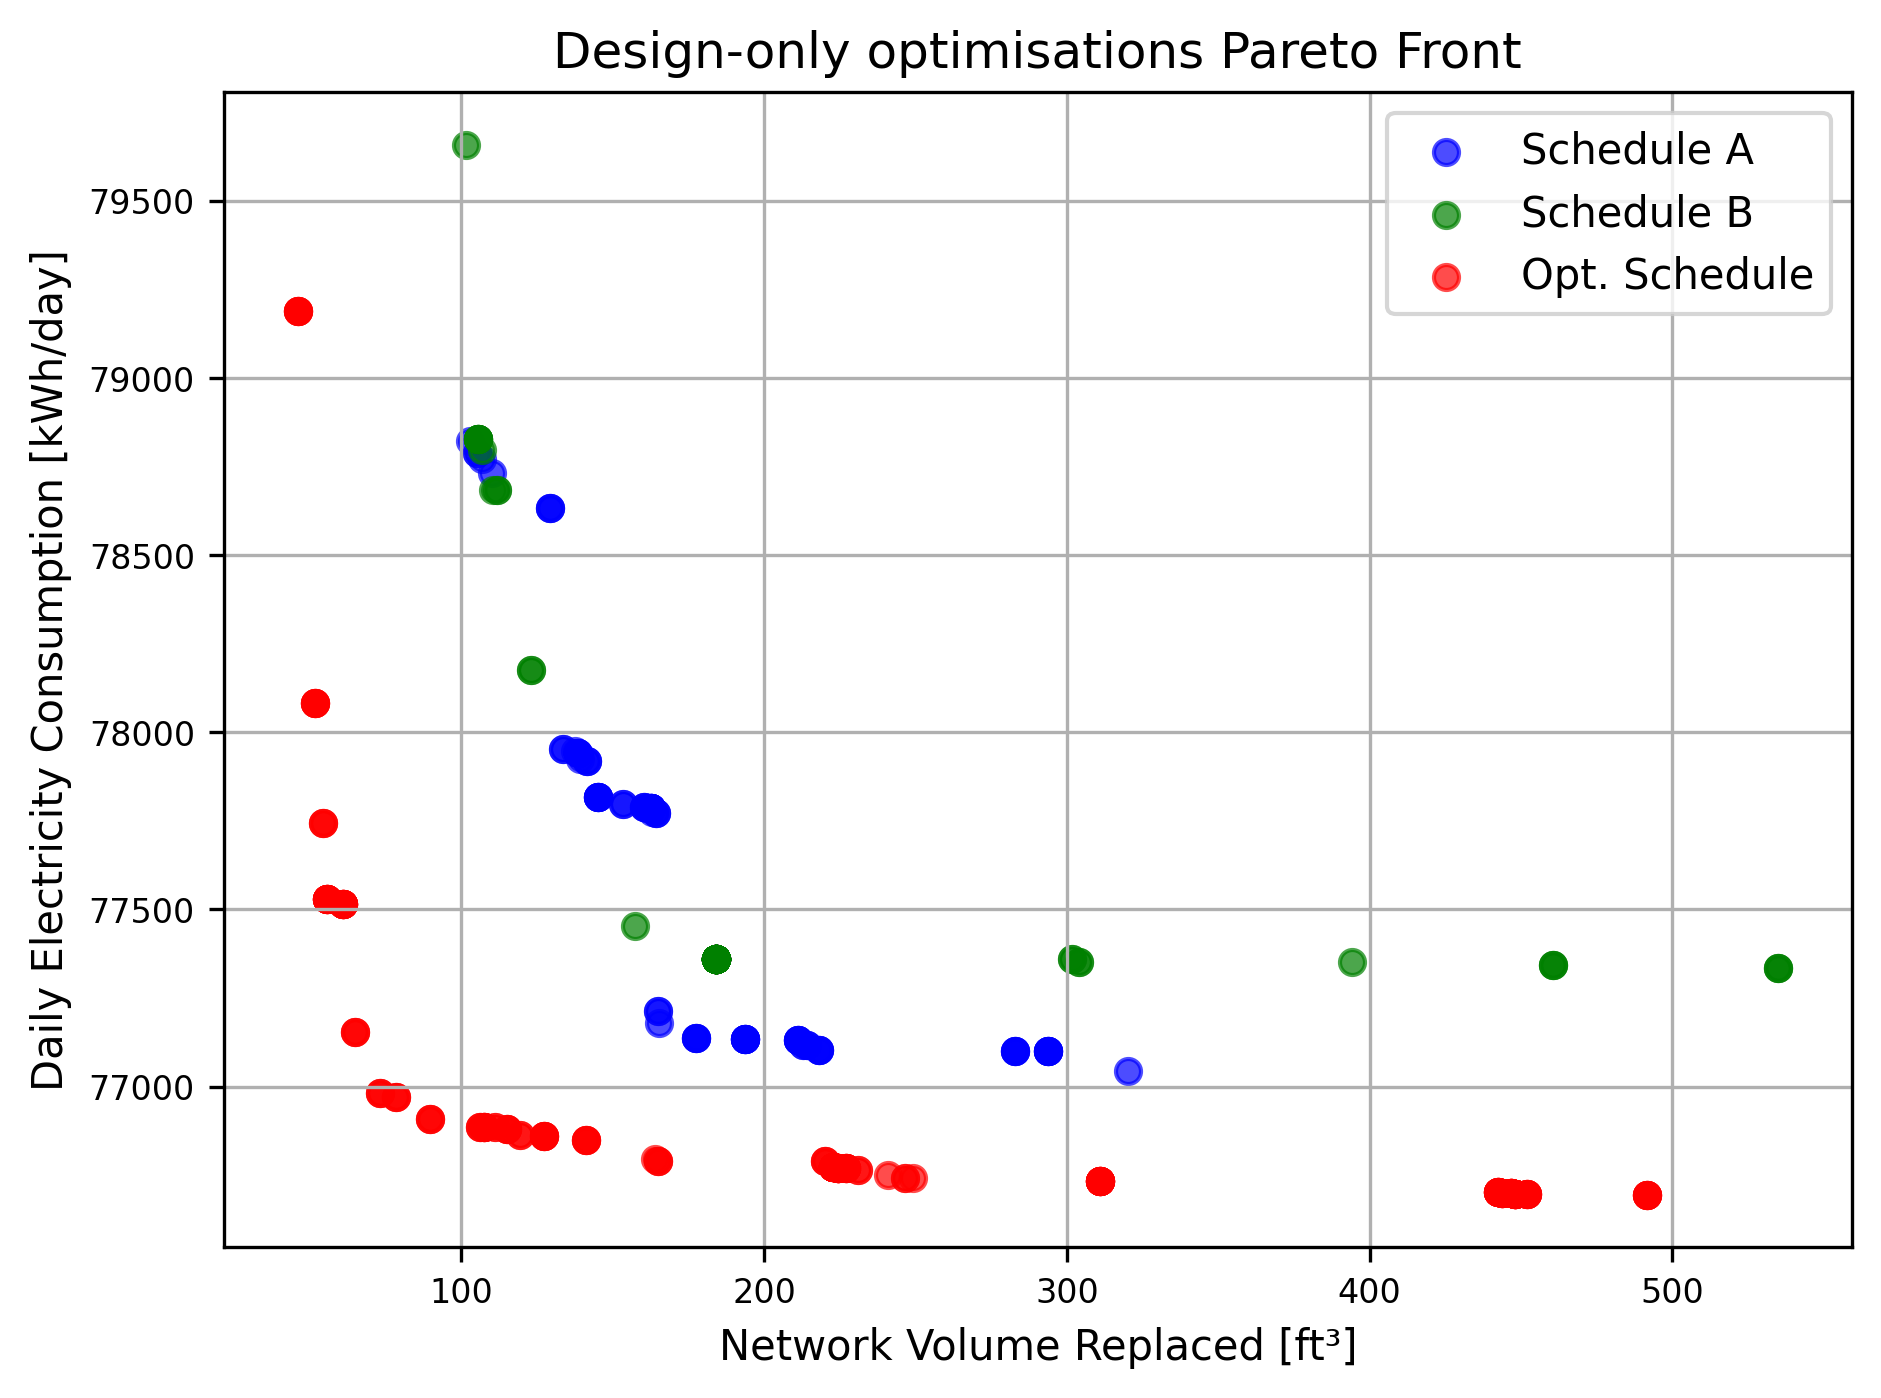

In [25]:
# Visualize the results of the optimisation of problems A and B alongside those of the integrated design & operations
plt.figure(figsize=(7,5))
view_valid_pareto(sol_design_prob_a, color='b', label="Schedule A")
view_valid_pareto(sol_design_prob_b, color='g', label="Schedule B")
view_valid_pareto(sol_integ_prob, color='r', label="Opt. Schedule")
plt.xlabel("Network Volume Replaced [ft³]")
plt.ylabel("Daily Electricity Consumption [kWh/day]")
plt.title("Design-only optimisations Pareto Front")
plt.grid(True)
plt.legend()
plt.show()


The integrated design-and-operation front is noticeably better than the design-only result. By co-optimising the pump schedule, the algorithm can make better use of the existing tanks which in turn allows it to find solutions with **less installed pipe volume** and **lower energy consumption** simultaneously. This is the core argument for integrated optimisation: fixing operations during design leaves significant performance on the table.

## Next Steps

The implementation presented here is a deliberate simplification. The following extensions would be needed to move toward a production-ready solver:

**Hydraulic fidelity**
- Re-evaluate all Pareto-optimal solutions at a finer hydraulic time step to verify feasibility — solutions that appear valid at 15-minute resolution may violate pressure or tank-level constraints at higher fidelity.
- Replace `getComputedHydraulicTimeSeries` with the `runH` / `nextH` loop to capture EPANET error codes at every time step and handle invalid solutions explicitly.

**Problem completeness**
- Implement the full Anytown cost function (pipe location, diameter, and rehabilitation type) to replace the pipe volume proxy.
- Add tank siting and sizing as decision variables, together with constraints enforcing a complete fill-empty cycle within the 24-hour horizon.
- Implement all five load scenarios (average day, instantaneous peak, three fire flow conditions). The cleanest approach is to maintain a separate pre-configured network object per scenario — switching simulation settings (duration, demand multiplier, fire flow nodes) at every evaluation is error-prone and slow. The open question is **how to aggregate constraints across load scenarios**: how do you handle a solution that is feasible under four conditions but fails one fire flow?

**Control variables**
- For variable-speed pumps, the discrete schedule can be generalised to a continuous decision variable: encode pump speed in the fractional part, so that a value of `2.5` means 2 pumps running at 50% speed. This extends the search space smoothly without requiring a separate variable type.

**Optimisation robustness**
- Run multiple independent seeds to assess solution quality and front stability — a single seed gives no information about variability.
- For parallel execution, use pygmo's island model carefully: each island needs its **own independent network object**. Sharing a single EPyT instance across concurrent evaluations will produce race conditions. The recommended pattern is a pre-allocated pool of network objects, one per worker.